In [117]:
!pip install mplfinance

In [118]:
!pip install yfinance

In [119]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [120]:
data = yf.download('AAPL', start='2020-01-01', end='2026-07-24')

[*********************100%***********************]  1 of 1 completed


In [121]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [122]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [123]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400


In [124]:
data.tail(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-07-10,315.320007,316.910004,312.170013,314.720001,34132300
2026-07-13,317.309998,323.450012,315.779999,317.019989,43257800
2026-07-14,314.859985,316.190002,311.910004,313.760010,36336800
2026-07-15,327.500000,328.730011,317.320007,317.619995,60957600
2026-07-16,333.260010,334.679993,326.790009,328.010010,62970600
2026-07-17,333.739990,334.989990,329.000000,331.980011,63407100
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000
2026-07-21,327.739990,329.600006,322.220001,323.130005,41338900
2026-07-22,325.890015,329.000000,323.339996,327.869995,38755900


In [125]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1647 non-null   float64
 1   High    1647 non-null   float64
 2   Low     1647 non-null   float64
 3   Open    1647 non-null   float64
 4   Volume  1647 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.2 KB


In [126]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [127]:
data.describe()


Price,Close,High,Low,Open,Volume
count,1647.000000,1647.000000,1647.000000,1647.000000,1.647000e+03
mean,174.227500,176.023192,172.267789,174.058002,8.165621e+07
std,57.443143,57.886306,56.955448,57.379694,5.051738e+07
min,54.163704,55.160702,51.324800,55.059313,1.791060e+07
25%,135.559029,137.916434,132.975617,134.940289,4.880845e+07
50%,168.504837,170.245725,167.143448,168.378185,6.725760e+07
75%,216.425232,218.462578,213.946491,215.900343,9.681695e+07
max,333.739990,334.989990,329.000000,333.510010,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

## Visualization

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

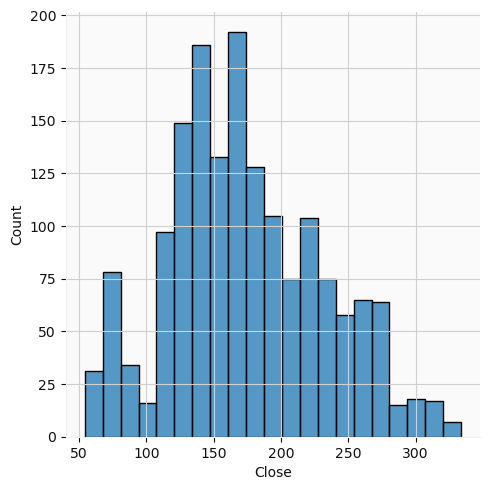

In [129]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

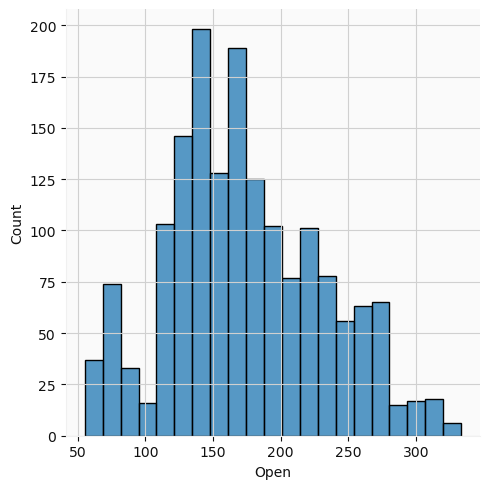

In [130]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

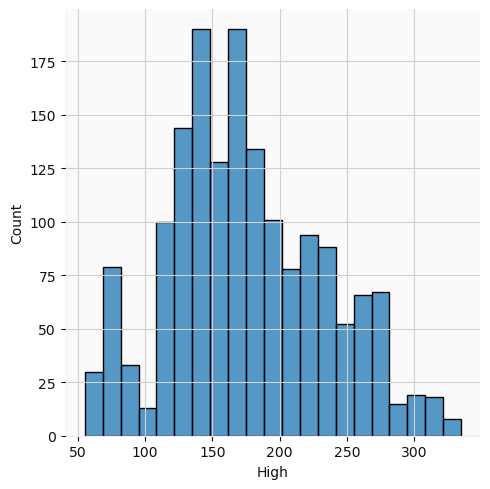

In [131]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

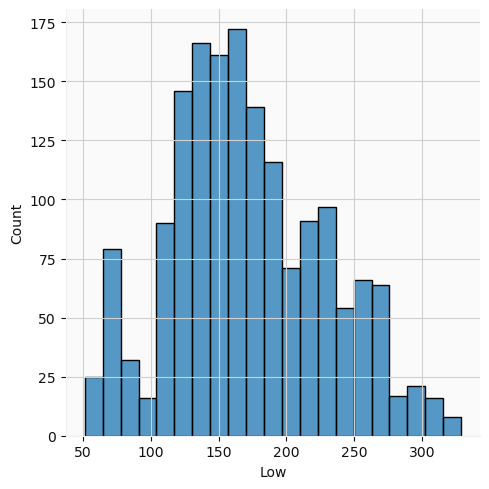

In [132]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [133]:
data.head()
type(data['Open'])

pandas.core.series.Series

In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1647 non-null   float64
 1   High    1647 non-null   float64
 2   Low     1647 non-null   float64
 3   Open    1647 non-null   float64
 4   Volume  1647 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.2 KB


In [135]:
data['Open'] = data['Open'].astype(float)   

/opt/anaconda3/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


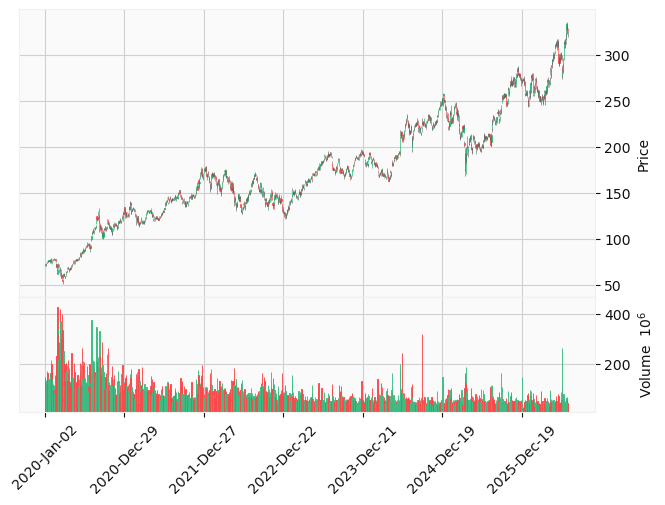

In [136]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

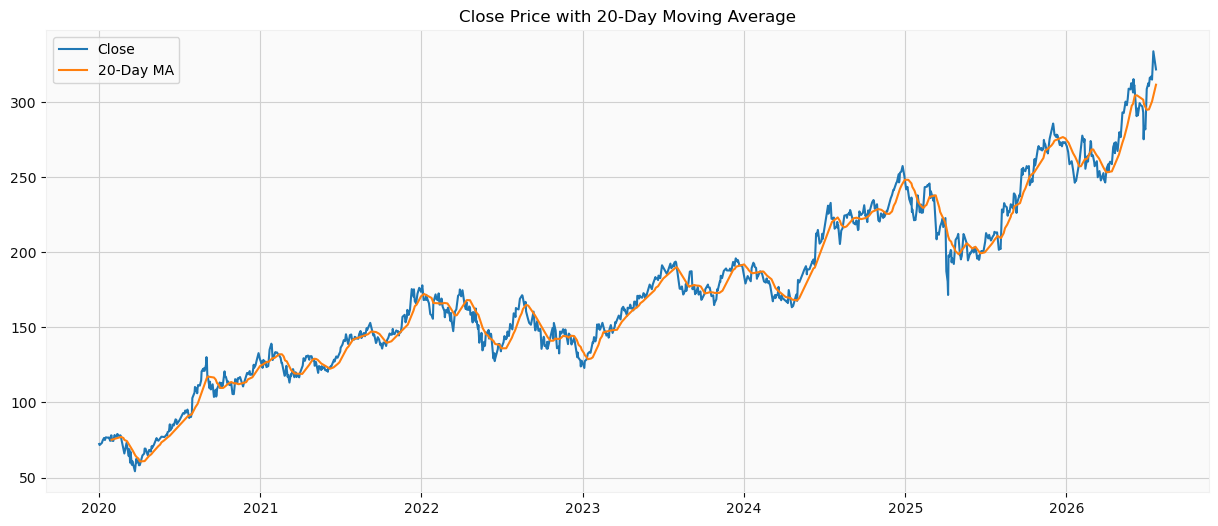

In [137]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [138]:
data['Close']

Date
2020-01-02     72.333900
2020-01-03     71.630646
2020-01-06     72.201416
2020-01-07     71.861855
2020-01-08     73.017830
                 ...    
2026-07-17    333.739990
2026-07-20    326.589996
2026-07-21    327.739990
2026-07-22    325.890015
2026-07-23    321.660004
Name: Close, Length: 1647, dtype: float64

In [139]:
# finish visuals

In [140]:
#6 Volume

In [141]:
data["Volume_MA20"] = (
    data["Volume"]
    .rolling(20)
    .mean()
)

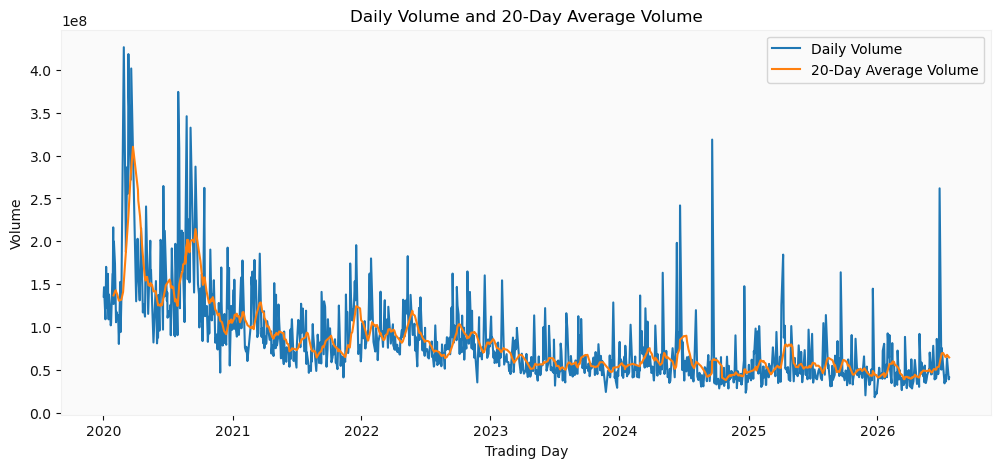

In [142]:
plt.figure(figsize=(12, 5))

plt.plot(data["Volume"], label="Daily Volume")
plt.plot(data["Volume_MA20"], label="20-Day Average Volume")

plt.title("Daily Volume and 20-Day Average Volume")
plt.xlabel("Trading Day")
plt.ylabel("Volume")
plt.legend()
plt.grid()

plt.show()

In [143]:
#Volume Change

In [144]:
data["Volume_Change"] = (
    data["Volume"]
    .pct_change()
)

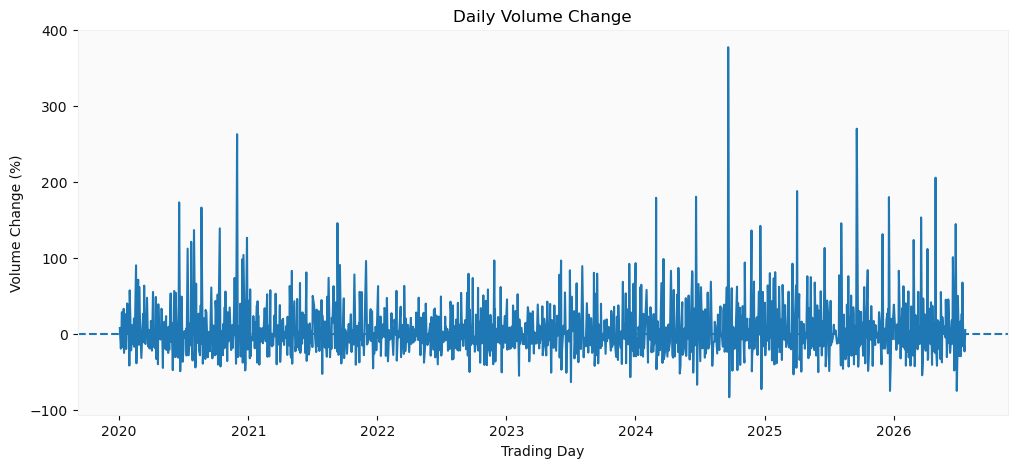

In [145]:
plt.figure(figsize=(12, 5))
plt.plot(data["Volume_Change"] * 100)
plt.axhline(y=0, linestyle="--")
plt.title("Daily Volume Change")
plt.xlabel("Trading Day")
plt.ylabel("Volume Change (%)")
plt.grid()

plt.show()

* We can see a high volume change during September 2020 - January 2021

In [146]:
#Relative volume

In [147]:
data["Relative_Volume"] = (
    data["Volume"] /
    data["Volume_MA20"]
)

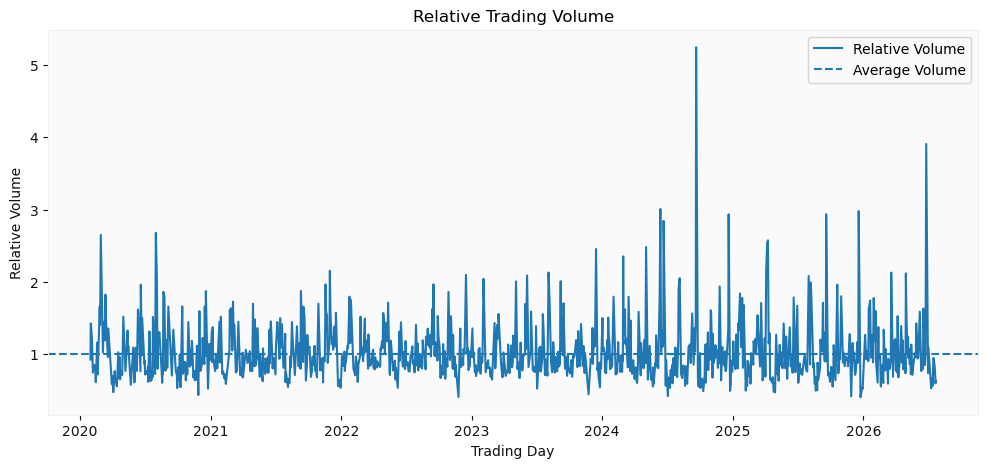

In [148]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Relative_Volume"],
    label="Relative Volume"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Average Volume"
)

plt.title("Relative Trading Volume")
plt.xlabel("Trading Day")
plt.ylabel("Relative Volume")
plt.legend()
plt.grid()

plt.show()

In [149]:
# 7

In [150]:
#Daily. Range

In [151]:
data["Daily_Range"] = (
    data["High"] -
    data["Low"]
)

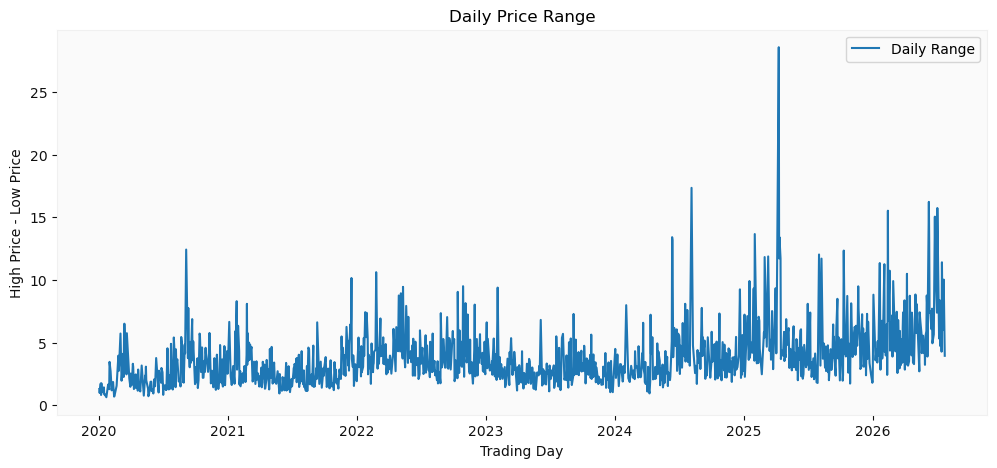

In [152]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Daily_Range"],
    label="Daily Range"
)

plt.title("Daily Price Range")
plt.xlabel("Trading Day")
plt.ylabel("High Price - Low Price")
plt.legend()
plt.grid()

plt.show()

In [153]:
#Close vs open

In [154]:
data["Close_Open_Diff"] = (
    data["Close"] -
    data["Open"]
)

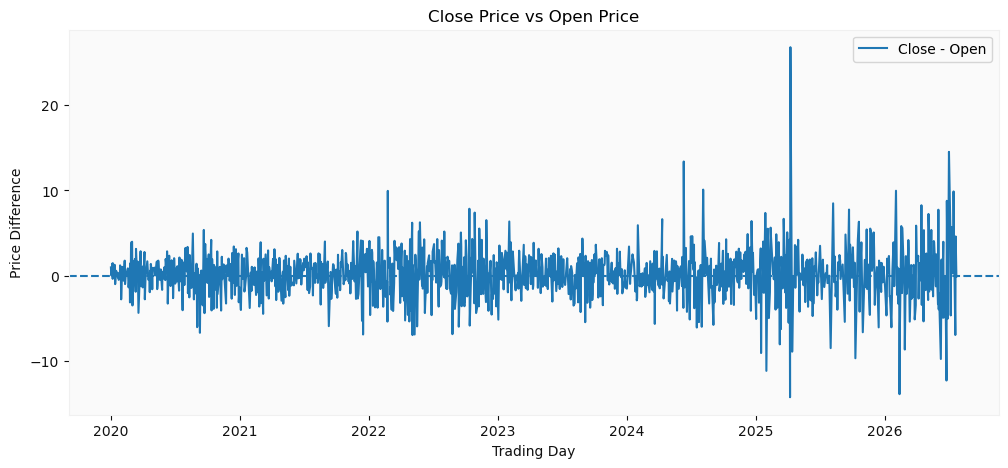

In [155]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Close_Open_Diff"],
    label="Close - Open"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Close Price vs Open Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [156]:
#High vs Close

In [157]:
data["High_Close_Diff"] = (
    data["High"] -
    data["Close"]
)

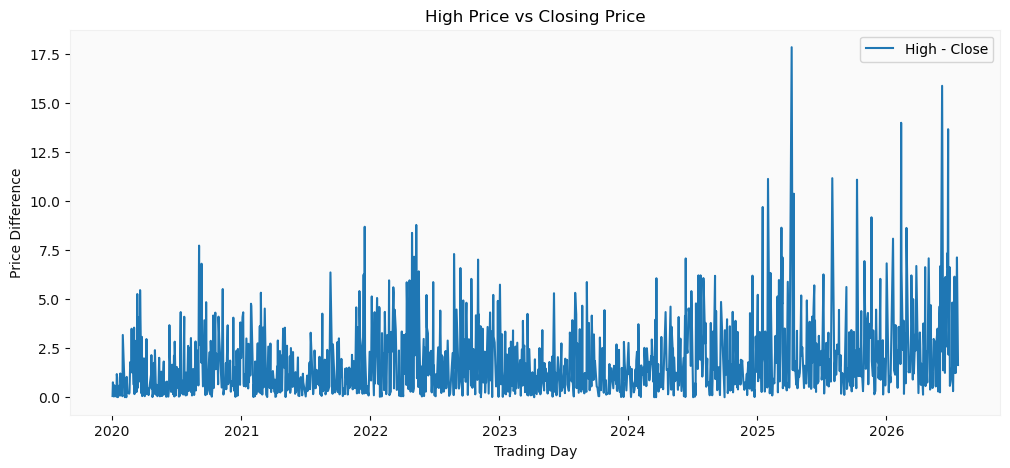

In [158]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["High_Close_Diff"],
    label="High - Close"
)

plt.title("High Price vs Closing Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [159]:
#8 Moving average features

In [160]:
data["MA10"] = data["Close"].rolling(10).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

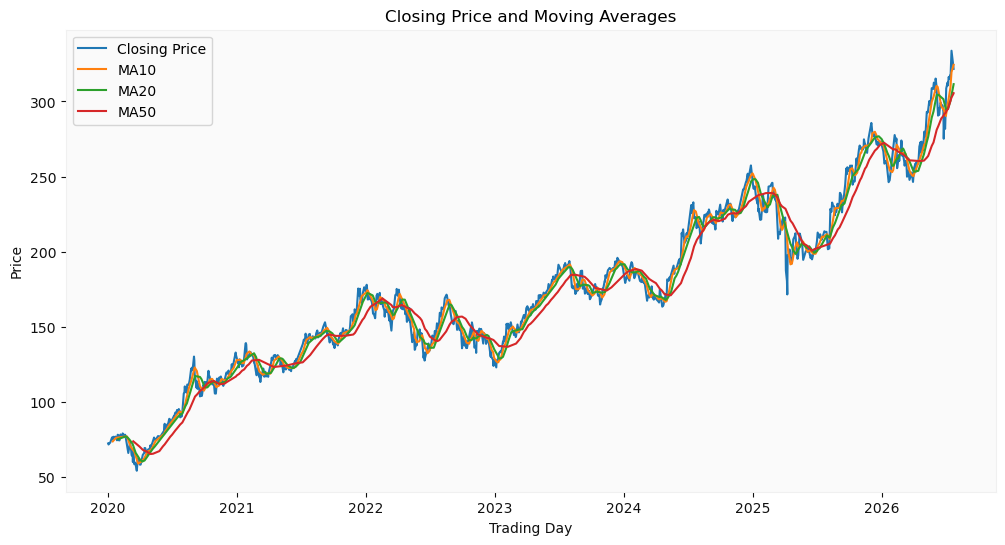

In [161]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA10"], label="MA10")
plt.plot(data["MA20"], label="MA20")
plt.plot(data["MA50"], label="MA50")

plt.title("Closing Price and Moving Averages")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [162]:
# Moving average diference

In [163]:
data["MA10_MA20"] = (
    data["MA10"] -
    data["MA20"]
)

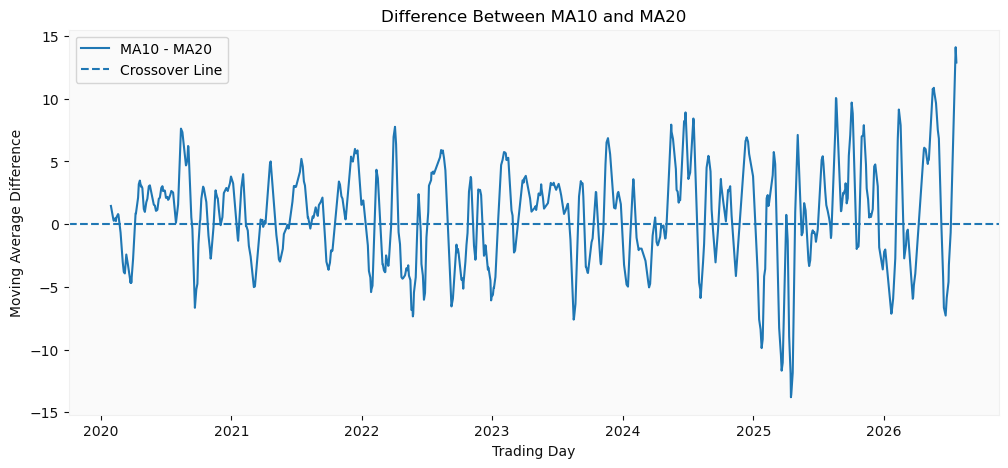

In [164]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["MA10_MA20"],
    label="MA10 - MA20"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Crossover Line"
)

plt.title("Difference Between MA10 and MA20")
plt.xlabel("Trading Day")
plt.ylabel("Moving Average Difference")
plt.legend()
plt.grid()

plt.show()

## Feature Enginering

In [165]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20
Date,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN


In [166]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close
Date,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN


In [167]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN,0.021241
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN,0.002261
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN,0.021364
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN,-0.013503


## Calendar Features

In [168]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086


In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            1647 non-null   float64
 1   High             1647 non-null   float64
 2   Low              1647 non-null   float64
 3   Open             1647 non-null   float64
 4   Volume           1647 non-null   int64  
 5   MA20             1628 non-null   float64
 6   Volume_MA20      1628 non-null   float64
 7   Volume_Change    1646 non-null   float64
 8   Relative_Volume  1628 non-null   float64
 9   Daily_Range      1647 non-null   float64
 10  Close_Open_Diff  1647 non-null   float64
 11  High_Close_Diff  1647 non-null   float64
 12  MA10             1638 non-null   float64
 13  MA50             1598 non-null   float64
 14  MA10_MA20        1628 non-null   float64
 15  MA50_Close       1598 non-null   float64
 16  Daily_Return     1646 non-null   float64
d

In [170]:
data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-07-10', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23'],
              dtype='datetime64[ns]', name='Date', length=1647, freq=None)

In [171]:
data["Day"] = data.index.day

In [172]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day
Date,,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8


In [173]:
data["Weekday"] = data.index.weekday

In [174]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday
Date,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2


In [175]:
data["Month"]= data.index.month

In [176]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0,1
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1


In [177]:
data["Year"] = data.index.year

In [178]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,1.302902,...,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,...,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1,2020
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,-0.190918,NaN,1.736396,...,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0,1,2020
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,...,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1,2020
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,NaN,NaN,0.213160,NaN,1.753256,...,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1,2020


In [179]:
# mean imputation
data['MA20']= data['MA20'].fillna(data['MA20'].mean())
data['MA50_Close']= data['MA50_Close'].fillna(data['MA50_Close'].mean())
data['Daily_Return']= data['Daily_Return'].fillna(data['Daily_Return'].mean())

In [180]:
data['Volume_MA20']= data['Volume_MA20'].fillna(data['Volume_MA20'].mean())
data['Volume_Change']= data['Volume_Change'].fillna(data['Volume_Change'].mean())
data['Relative_Volume']= data['Relative_Volume'].fillna(data['Relative_Volume'].mean())
data['MA10']= data['MA10'].fillna(data['MA10'].mean())
data['MA50']= data['MA50'].fillna(data['MA50'].mean())
data['MA10_MA20']= data['MA10_MA20'].fillna(data['MA10_MA20'].mean())

In [181]:
data.isnull().sum()

Price
Close              0
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
Close_Open_Diff    0
High_Close_Diff    0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [182]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,173.95599,8.154419e+07,0.046637,1.000492,1.302902,...,0.060208,174.088138,173.684148,0.739015,173.684148,0.001102,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,173.95599,8.154419e+07,0.080029,1.000492,0.982591,...,0.758619,174.088138,173.684148,0.739015,173.684148,-0.009722,3,4,1,2020
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,173.95599,8.154419e+07,-0.190918,1.000492,1.736396,...,0.038534,174.088138,173.684148,0.739015,173.684148,0.007968,6,0,1,2020
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,173.95599,8.154419e+07,-0.080374,1.000492,0.823641,...,0.604483,174.088138,173.684148,0.739015,173.684148,-0.004703,7,1,1,2020
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,173.95599,8.154419e+07,0.213160,1.000492,1.753256,...,0.301040,174.088138,173.684148,0.739015,173.684148,0.016086,8,2,1,2020


## Feature Selection

In [183]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'Volume_MA20',
       'Volume_Change', 'Relative_Volume', 'Daily_Range', 'Close_Open_Diff',
       'High_Close_Diff', 'MA10', 'MA50', 'MA10_MA20', 'MA50_Close',
       'Daily_Return', 'Day', 'Weekday', 'Month', 'Year'],
      dtype='object', name='Price')

In [184]:
x = data.drop(columns = ['Close', 'High_Close_Diff','Close_Open_Diff'], axis = 1)


In [185]:
y = data['Close']

## Time-Series (Train, Test, Split)

In [186]:
# Normal dataset
from sklearn.model_selection import train_test_split

In [187]:
train_size = int(len(x)*0.7)
val_size = int(len(x)*0.3)

In [188]:
x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

In [189]:
train_size

1152

In [190]:
x_test = x.iloc[train_size:]
y_test = y.iloc[train_size:]


In [191]:
print(f"x_train = {x_train.shape}")
print(f"y_train = {y_train.shape}")

x_train = (1152, 18)
y_train = (1152,)


In [192]:
print(f"x_test = {x_test.shape}")
print(f"y_test = {y_test.shape}")

x_test = (495, 18)
y_test = (495,)


## Model Training 

In [193]:
from sklearn.linear_model import LinearRegression

In [194]:
model = LinearRegression()

In [195]:
x.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   High             1647 non-null   float64
 1   Low              1647 non-null   float64
 2   Open             1647 non-null   float64
 3   Volume           1647 non-null   int64  
 4   MA20             1647 non-null   float64
 5   Volume_MA20      1647 non-null   float64
 6   Volume_Change    1647 non-null   float64
 7   Relative_Volume  1647 non-null   float64
 8   Daily_Range      1647 non-null   float64
 9   MA10             1647 non-null   float64
 10  MA50             1647 non-null   float64
 11  MA10_MA20        1647 non-null   float64
 12  MA50_Close       1647 non-null   float64
 13  Daily_Return     1647 non-null   float64
 14  Day              1647 non-null   int32  
 15  Weekday          1647 non-null   int32  
 16  Month            1647 non-null   int32  
 

In [196]:
x.isna().sum()

Price
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [197]:
x_train.isnull().sum()

Price
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [198]:
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [199]:
predictions = model.predict(x_test)

In [200]:
predictions

array([217.32885814, 220.74182528, 203.56607482, 203.78732923,
       209.78580088, 209.93190908, 213.87916042, 216.72133385,
       219.82974924, 220.09384376, 222.65774218, 224.22390424,
       222.45097985, 224.91319336, 224.86050868, 223.72329719,
       225.22699079, 223.65928751, 225.63271552, 225.88225698,
       229.8817531 , 226.70195471, 221.64840676, 217.22380535,
       222.80067518, 220.29986827, 216.7454623 , 217.50139578,
       219.048509  , 219.91941827, 221.15131915, 212.69220121,
       214.16616565, 219.879418  , 227.39513837, 227.623045  ,
       225.8197488 , 225.67742267, 224.12260157, 225.4053367 ,
       226.79912639, 230.66032208, 223.32932766, 223.62962347,
       223.40694639, 224.16614635, 220.96685578, 223.77136289,
       226.97527073, 226.88378105, 226.29222188, 229.47227513,
       233.92798154, 228.87299498, 230.22954716, 233.33094334,
       234.44126092, 232.74468299, 228.27703683, 227.84526598,
       230.35792742, 232.22320919, 231.64362141, 228.90

In [201]:
data_pred = pd.DataFrame(y_test)
data_pred['Predictions Value'] = predictions
#data_pred['Actual Value'] = y_test


In [202]:
data_pred

,Close,Predictions Value
Date,,
2024-08-01,216.484711,217.328858
2024-08-02,217.971832,220.741825
2024-08-05,207.472794,203.566075
2024-08-06,205.450287,203.787329
2024-08-07,208.018051,209.785801
...,...,...
2026-07-17,333.739990,332.128669
2026-07-20,326.589996,326.700108
2026-07-21,327.739990,327.102228


## Model Evaluation

In [203]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [204]:
#Calculate mse
mse = mean_squared_error(y_test, predictions)

In [205]:
print(f"MSE:{mse:.4f}")
print(f"MSE:{mse}")

MSE:1.7924
MSE:1.7923934306430778


In [206]:
rmse = root_mean_squared_error(y_test, predictions)
print(f"RMSE:{rmse:.4f}")

RMSE:1.3388


## Saving ML Model

In [207]:
import joblib

In [208]:
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

### Loading the saved model

In [209]:
saved_model = joblib.load('linear_regression_model.pkl')

In [210]:
saved_predictions = saved_model.predict(x_test)

In [211]:
saved_predictions

array([217.32885814, 220.74182528, 203.56607482, 203.78732923,
       209.78580088, 209.93190908, 213.87916042, 216.72133385,
       219.82974924, 220.09384376, 222.65774218, 224.22390424,
       222.45097985, 224.91319336, 224.86050868, 223.72329719,
       225.22699079, 223.65928751, 225.63271552, 225.88225698,
       229.8817531 , 226.70195471, 221.64840676, 217.22380535,
       222.80067518, 220.29986827, 216.7454623 , 217.50139578,
       219.048509  , 219.91941827, 221.15131915, 212.69220121,
       214.16616565, 219.879418  , 227.39513837, 227.623045  ,
       225.8197488 , 225.67742267, 224.12260157, 225.4053367 ,
       226.79912639, 230.66032208, 223.32932766, 223.62962347,
       223.40694639, 224.16614635, 220.96685578, 223.77136289,
       226.97527073, 226.88378105, 226.29222188, 229.47227513,
       233.92798154, 228.87299498, 230.22954716, 233.33094334,
       234.44126092, 232.74468299, 228.27703683, 227.84526598,
       230.35792742, 232.22320919, 231.64362141, 228.90

In [212]:
mse = mean_squared_error(y_test, saved_predictions)

In [213]:
mse

1.7923934306430778

In [214]:
x_train.iloc[0]

Price
High               7.239411e+01
Low                7.109121e+01
Open               7.134408e+01
Volume             1.354804e+08
MA20               1.739560e+02
Volume_MA20        8.154419e+07
Volume_Change      4.663676e-02
Relative_Volume    1.000492e+00
Daily_Range        1.302902e+00
MA10               1.740881e+02
MA50               1.736841e+02
MA10_MA20          7.390147e-01
MA50_Close         1.736841e+02
Daily_Return       1.101732e-03
Day                2.000000e+00
Weekday            3.000000e+00
Month              1.000000e+00
Year               2.020000e+03
Name: 2020-01-02 00:00:00, dtype: float64

In [215]:
import numpy as np
x_train.iloc[0].ndim
record = np.array(x_train.iloc[100]).reshape(1, -1)

In [216]:
record.ndim

2

In [217]:
one_prediction = saved_model.predict(record)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [218]:
one_prediction

array([76.48742236])

In [219]:
y_train.iloc[100]

np.float64(77.00072479248047)

In [226]:
x_train.columns

Index(['High', 'Low', 'Open', 'Volume', 'MA20', 'Volume_MA20', 'Volume_Change',
       'Relative_Volume', 'Daily_Range', 'MA10', 'MA50', 'MA10_MA20',
       'MA50_Close', 'Daily_Return', 'Day', 'Weekday', 'Month', 'Year'],
      dtype='object', name='Price')